## CONSTRAINED

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))
#IMPORTS
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd
import numpy as np
from sklearn.decomposition import FastICA
from src.visualizacion import *
from src.evaluacion import *
from src.metricas import *
from src.preprocesamiento import *
from src.io_utils import *
from src.sobi import *
from scipy import signal
from src.constrained_ica import *
#VARIABLES
fs=1000
window_size=200
salto=50

In [2]:
mat=load_mat("C:/Users/34648/Desktop/Clases/4_GITT/TFG/OPENICPSR/TR2_postTMR_32chanEMG.mat")

In [ ]:
X1, key1 = find_movement_rep(mat, movement="HandOpen", rep=1)
X2, key2 = find_movement_rep(mat, movement="noMotion", rep=1)  

print("Señal 1 extraída de:", key1)
print("Señal 2 extraída de:", key2)


ch_s1 = 3
ch_s2 = 20

u1 = eliminar_continua(X1[:, ch_s1].astype(float))
u2_raw = eliminar_continua(X1[:, ch_s2].astype(float))  


#Longitudes
N = min(len(u1), len(u2_raw))
u1 = u1[:N]

u2_raw = u2_raw[:N]
N = len(u1)
t = np.arange(N) / fs

m1 = np.zeros(N)
m2 = np.zeros(N)
m3 = np.zeros(N)
#bloques 5 segundos
bloque = int(0.2 * fs)
bloque2 = int(0.2 * fs)


patron = [0, 3, 2,1, 3, 3, 1, 2, 3, 0,2, 3,1]

for i, estado in enumerate(patron):
    a = i * bloque
    a2= i * bloque2
    b = min((i + 1) * bloque, N)
    b2= min((i + 1) * bloque2, N)
    if estado == 1:
        m1[a:b] = 1.0
        m3[a:b] = 1.0
    elif estado == 2:
        m2[a2:b2] = 1.0
    elif estado == 3:
        m1[a:b] = 1.0
        m3[a:b] = 1.0
        m2[a2:b2] = 1.0


#CONSTRUCCION DE SEÑALES

s1 = m1 * u1
s2 = m2 * u2_raw


#RETARDOS DE S2
tau_ms = 10
tau = int(fs * tau_ms / 1000)

s2_delayed = np.zeros_like(s2)

if tau < len(s2):
    s2_delayed[tau:] = s2[:-tau]

#MEZCLAS
beta = 1
noise_std = 0.0

rng = np.random.default_rng(0)
n1 = noise_std * rng.standard_normal(len(s1))
n2 = noise_std * rng.standard_normal(len(s1))

c1 = 1.0 * s1 + beta * s2_delayed + n1
c2 = 0.01 * s1 + 1.0 * s2 + n2

X_mix = np.column_stack([c1, c2])
S_true = np.column_stack([s1, s2_delayed])

Señal 1 extraída de: HandOpen_1.DAQ_DATA
Señal 2 extraída de: NoMotion_1.DAQ_DATA


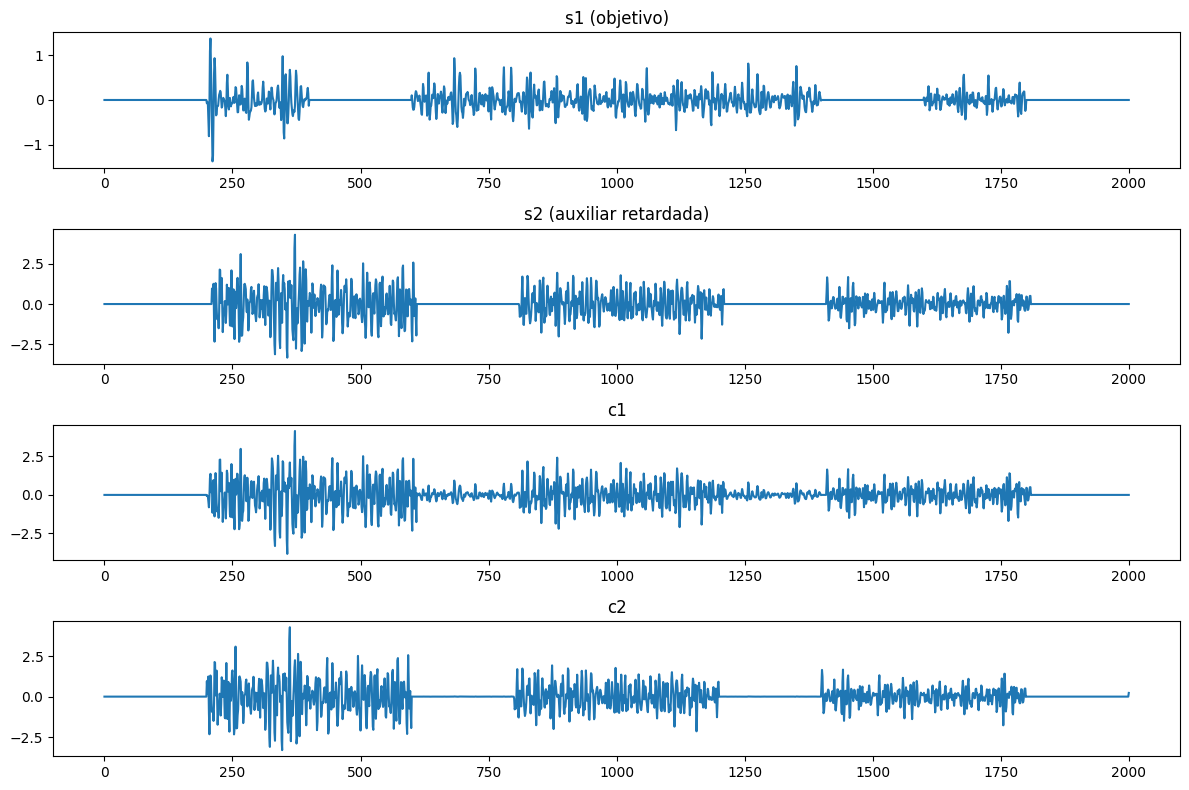

In [4]:
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(s1)
plt.title("s1 (objetivo)")

plt.subplot(4, 1, 2)
plt.plot(s2_delayed)
plt.title("s2 (auxiliar retardada)")

plt.subplot(4, 1, 3)
plt.plot(c1)
plt.title("c1")

plt.subplot(4, 1, 4)
plt.plot(c2)
plt.title("c2")

plt.tight_layout()
plt.show()

# 1unit_constrained

In [5]:
case = build_case(
    u1=u1, u2_raw=u2_raw, fs=fs,
    a11=1.0, a21=0.01, beta=1,
    tau_ms=2.0, noise_std=0.1,
    block_ms=200,
    random_state=0
)

X = case["X"]
S_true = case["S_true"]

In [6]:
ref_s1_binary = m1.astype(float)
ref_env = np.abs(s1)
ref_env = np.convolve(ref_env, np.ones(50)/50, mode="same")
ref_env = ref_env / (np.max(ref_env) + 1e-12)
y_c, w_c, info = constrained_fastica_oneunit(
    X,
    ref=ref_s1_binary,         
    lambda_ref=0.0,
    max_lag=2,
    random_state=0,
    smooth_ref=True,
    smooth_win=75,
    init_mode="ref"
)

In [7]:
from src.metricas import safe_corr, rms_envelope_metrics, snr_db

corr = safe_corr(y_c, s1)
env = rms_envelope_metrics(s1, y_c, fs=1000, window_ms=150, step_ms=50)
snr = snr_db(s1, y_c)

print("corr =", corr)
print("corr_rms =", env["corr_rms"])
print("snr_db =", snr)
print("best_lag =", info["best_lag"])

corr = -0.041916956659200116
corr_rms = -0.1554251677897214
snr_db = 0.007637398756308857
best_lag = -2


In [8]:
results = []

for lam in [0.0, 0.05, 0.1, 0.2]:
    y_c, w_c, info = constrained_fastica_oneunit(
        X,
        ref=ref_s1_binary,         
        lambda_ref=lam,
        max_lag=5,
        random_state=0,
        smooth_ref=True,
        smooth_win=25,
        init_mode="ref"
    )

    corr = safe_corr(y_c, s1)
    env = rms_envelope_metrics(s1, y_c, fs=1000, window_ms=150, step_ms=50)
    snr = snr_db(s1, y_c)

    results.append({
        "lambda_ref": lam,
        "corr": corr,
        "abs_corr": abs(corr),
        "corr_rms": env["corr_rms"],
        "snr_db": snr,
        "best_lag": info["best_lag"],
        "q_score": info["q_score"],
        "n_iter": info["n_iter"],
        "converged": info["converged"],
    })

df_results = pd.DataFrame(results)
display(df_results.sort_values("lambda_ref").reset_index(drop=True))

,lambda_ref,corr,abs_corr,corr_rms,snr_db,best_lag,q_score,n_iter,converged
0,0.00,-0.041889,0.041889,-0.155424,0.007627,-5,0.005149,78,True
1,0.05,-0.047607,0.047607,-0.155641,0.009854,-5,0.005149,1000,False
2,0.10,-0.317737,0.317737,0.052548,0.462194,-5,0.005149,18,True
3,0.20,-0.072634,0.072634,-0.154126,0.022972,-5,0.005149,1000,False


In [9]:
import pandas as pd
from sklearn.decomposition import FastICA
from src.metricas import safe_corr, rms_envelope_metrics, snr_db

results = []


ica = FastICA(
    n_components=2,
    whiten="unit-variance",
    random_state=0,
    max_iter=2000,
    tol=1e-5
)
S_hat = ica.fit_transform(X)

#escoger la componente que mejor correlacione con s1
corrs = [safe_corr(S_hat[:, i], s1) for i in range(S_hat.shape[1])]
best_idx = int(abs(corrs[1]) > abs(corrs[0]))
y_ica = S_hat[:, best_idx]

corr = safe_corr(y_ica, s1)
env = rms_envelope_metrics(s1, y_ica, fs=1000, window_ms=150, step_ms=50)
snr = snr_db(s1, y_ica)

results.append({
    "method": "FastICA",
    "lambda_ref": None,
    "corr": corr,
    "abs_corr": abs(corr),
    "corr_rms": env["corr_rms"],
    "snr_db": snr,
    "best_lag": None,
    "q_score": None,
})


for lam in [0.0, 0.05, 0.1, 0.2,0.5,1,10,50,100]:
    y_c, w_c, info = constrained_fastica_oneunit(
        X,
        ref=ref_s1_binary,
        lambda_ref=lam,
        max_lag=5,
        random_state=72,
        smooth_ref=True,
        smooth_win=50,
        init_mode="ref"
    )

    corr = safe_corr(y_c, s1)
    env = rms_envelope_metrics(s1, y_c, fs=1000, window_ms=150, step_ms=50)
    snr = snr_db(s1, y_c)

    results.append({
        "method": "Constrained one-unit",
        "lambda_ref": lam,
        "corr": corr,
        "abs_corr": abs(corr),
        "corr_rms": env["corr_rms"],
        "snr_db": snr,
        "best_lag": info["best_lag"],
        "q_score": info["q_score"],
    })

df_results = pd.DataFrame(results)
display(df_results.reset_index(drop=True))

,method,lambda_ref,corr,abs_corr,corr_rms,snr_db,best_lag,q_score
0,FastICA,NaN,-0.234846,0.234846,0.000706,0.246384,NaN,NaN
1,Constrained one-unit,0.00,-0.041935,0.041935,-0.155426,0.007644,-5.0,0.004598
2,Constrained one-unit,0.05,-0.047595,0.047595,-0.155640,0.009849,-5.0,0.004598
3,Constrained one-unit,0.10,-0.055326,0.055326,-0.155603,0.013314,-5.0,0.004598
4,Constrained one-unit,0.20,-0.292903,0.292903,0.046205,0.389549,-5.0,0.004598
5,Constrained one-unit,0.50,-0.134332,0.134332,-0.134340,0.079085,-5.0,0.004598
6,Constrained one-unit,1.00,-0.217504,0.217504,-0.078520,0.210474,-5.0,0.004598
7,Constrained one-unit,10.00,-0.288911,0.288911,0.043429,0.378532,-5.0,0.004598
8,Constrained one-unit,50.00,-0.288939,0.288939,0.043449,0.378608,-5.0,0.004598
9,Constrained one-unit,100.00,-0.288942,0.288942,0.043451,0.378616,-5.0,0.004598


# DUAL REF

In [10]:
ref_s1_binary = m1.astype(float)
ref_s2_binary = m2.astype(float)

In [11]:
case = build_case(
    u1=u1, u2_raw=u2_raw, fs=fs,
    a11=1, a21=0.01, beta=0.3,
    tau_ms=2.0, noise_std=0.0,
    block_ms=200,
    random_state=0
)

X = case["X"]
S_true = case["S_true"]
m1=case["m1"]
m2=case["m2"]
ref_s1_binary = m1.astype(float)
ref_s2_binary = m2.astype(float)


In [12]:
import pandas as pd
from sklearn.decomposition import FastICA
from src.metricas import safe_corr, rms_envelope_metrics, snr_db


results = []


ica = FastICA(
    n_components=2,
    whiten="unit-variance",
    random_state=0,
    max_iter=2000,
    tol=1e-5
)
S_hat = ica.fit_transform(X)

corrs = [safe_corr(S_hat[:, i], s1) for i in range(S_hat.shape[1])]
best_idx = int(abs(corrs[1]) > abs(corrs[0]))
y_ica = S_hat[:, best_idx]

corr = safe_corr(y_ica, s1)
env = rms_envelope_metrics(s1, y_ica, fs=1000, window_ms=150, step_ms=50)
snr = snr_db(s1, y_ica)

results.append({
    "method": "FastICA",
    "lambda_pos": None,
    "lambda_neg": None,
    "corr": corr,
    "abs_corr": abs(corr),
    "corr_rms": env["corr_rms"],
    "snr_db": snr,
    "lag_target": None,
    "lag_bad": None,
    "score_target": None,
    "score_bad": None,
    "converged": None,
})


lambda_pos_values = [0.0, 0.2,0.5,0.75,1,5,10]
lambda_neg_values = [0.0, 0.05, 0.1, 0.2, 0.5,1,5]

for lam_pos in lambda_pos_values:
    for lam_neg in lambda_neg_values:
        y_dual, w_dual, info_dual = constrained_fastica_dualref_oneunit(
            X,
            ref_target=ref_s1_binary,
            ref_bad=ref_s2_binary,
            lambda_pos=lam_pos,
            lambda_neg=lam_neg,
            max_lag=2,
            random_state=0,
            smooth_ref=True,
            smooth_win=15,
            init_mode="target"
        )

        corr = safe_corr(y_dual, s1)
        env = rms_envelope_metrics(s1, y_dual, fs=1000, window_ms=150, step_ms=50)
        snr = snr_db(s1, y_dual)

        results.append({
            "method": "Dual-ref constrained",
            "lambda_pos": lam_pos,
            "lambda_neg": lam_neg,
            "corr": corr,
            "abs_corr": abs(corr),
            "corr_rms": env["corr_rms"],
            "snr_db": snr,
            "lag_target": info_dual["lag_target"],
            "lag_bad": info_dual["lag_bad"],
            "score_target": info_dual["score_target"],
            "score_bad": info_dual["score_bad"],
            "converged": info_dual["converged"],
        })

df_dual = pd.DataFrame(results)


display(df_dual)

display(
    df_dual[df_dual["method"] == "Dual-ref constrained"]
    .sort_values(["abs_corr", "corr_rms", "snr_db"], ascending=False)
    .reset_index(drop=True)
)

,method,lambda_pos,lambda_neg,corr,abs_corr,corr_rms,snr_db,lag_target,lag_bad,score_target,score_bad,converged
0,FastICA,NaN,NaN,0.712614,0.712614,0.703959,3.078750,NaN,NaN,NaN,NaN,None
1,Dual-ref constrained,0.00,0.00,0.039719,0.039719,-0.157470,0.006857,-2.0,2.0,0.002104,0.000933,True
2,Dual-ref constrained,0.00,0.05,-0.673013,0.673013,0.654906,2.619703,-2.0,2.0,0.002104,0.000933,True
3,Dual-ref constrained,0.00,0.10,0.653367,0.653367,0.626312,2.417605,-2.0,2.0,0.002104,0.000933,True
4,Dual-ref constrained,0.00,0.20,0.642665,0.642665,0.610301,2.313750,-2.0,2.0,0.002104,0.000933,True
5,Dual-ref constrained,0.00,0.50,0.636562,0.636562,0.601066,2.256370,-2.0,2.0,0.002104,0.000933,True
6,Dual-ref constrained,0.00,1.00,-0.634606,0.634606,0.598093,2.238258,-2.0,2.0,0.002104,0.000933,True
7,Dual-ref constrained,0.00,5.00,0.633079,0.633079,0.595767,2.224201,-2.0,2.0,0.002104,0.000933,True
8,Dual-ref constrained,0.20,0.00,0.384776,0.384776,0.128816,0.695871,-2.0,2.0,0.002104,0.000933,True
9,Dual-ref constrained,0.20,0.05,-0.408980,0.408980,0.160733,0.794928,-2.0,2.0,0.002104,0.000933,True


,method,lambda_pos,lambda_neg,corr,abs_corr,corr_rms,snr_db,lag_target,lag_bad,score_target,score_bad,converged
0,Dual-ref constrained,0.75,1.00,-0.709376,0.709376,0.701866,3.038307,-2.0,2.0,0.002104,0.000933,True
1,Dual-ref constrained,0.20,0.20,0.703101,0.703101,0.679752,2.961511,-2.0,2.0,0.002104,0.000933,True
2,Dual-ref constrained,0.50,0.50,0.699923,0.699923,0.673471,2.923374,-2.0,2.0,0.002104,0.000933,True
3,Dual-ref constrained,1.00,1.00,-0.698583,0.698583,0.670850,2.907457,-2.0,2.0,0.002104,0.000933,True
4,Dual-ref constrained,5.00,5.00,-0.697391,0.697391,0.668526,2.893361,-2.0,2.0,0.002104,0.000933,True
5,Dual-ref constrained,0.50,1.00,-0.680706,0.680706,0.665724,2.703177,-2.0,2.0,0.002104,0.000933,True
6,Dual-ref constrained,0.00,0.05,-0.673013,0.673013,0.654906,2.619703,-2.0,2.0,0.002104,0.000933,True
7,Dual-ref constrained,0.20,0.50,-0.671514,0.671514,0.652769,2.603733,-2.0,2.0,0.002104,0.000933,True
8,Dual-ref constrained,0.00,0.10,0.653367,0.653367,0.626312,2.417605,-2.0,2.0,0.002104,0.000933,True
9,Dual-ref constrained,0.20,1.00,-0.649169,0.649169,0.620062,2.376369,-2.0,2.0,0.002104,0.000933,True


In [13]:
dual_only = df_dual[df_dual["method"] == "Dual-ref constrained"].copy()

pivot_abs_corr = dual_only.pivot(index="lambda_pos", columns="lambda_neg", values="abs_corr")
pivot_corr_rms = dual_only.pivot(index="lambda_pos", columns="lambda_neg", values="corr_rms")
pivot_snr = dual_only.pivot(index="lambda_pos", columns="lambda_neg", values="snr_db")

print("Mapa abs_corr")
display(pivot_abs_corr)

print("Mapa corr_rms")
display(pivot_corr_rms)

print("Mapa snr_db")
display(pivot_snr)

Mapa abs_corr


lambda_neg,0.00,0.05,0.10,0.20,0.50,1.00,5.00
lambda_pos,,,,,,,
0.00,0.039719,0.673013,0.653367,0.642665,0.636562,0.634606,0.633079
0.20,0.384776,0.408980,0.470208,0.703101,0.671514,0.649169,0.635575
0.50,0.561025,0.552971,0.543052,0.514957,0.699923,0.680706,0.639618
0.75,0.560900,0.555517,0.549380,0.533924,0.435965,0.709376,0.643288
1.00,0.560834,0.556783,0.552299,0.541785,0.488406,0.698583,0.647260
5.00,0.560606,0.559801,0.558980,0.557283,0.551732,0.540583,0.697391
10.00,0.560581,0.560178,0.559771,0.558945,0.556355,0.551651,0.481592


Mapa corr_rms


lambda_neg,0.00,0.05,0.10,0.20,0.50,1.00,5.00
lambda_pos,,,,,,,
0.00,-0.157470,0.654906,0.626312,0.610301,0.601066,0.598093,0.595767
0.20,0.128816,0.160733,0.250494,0.679752,0.652769,0.620062,0.599566
0.50,0.483714,0.471136,0.455686,0.412313,0.673471,0.665724,0.605699
0.75,0.483519,0.475110,0.465536,0.441521,0.295651,0.701866,0.611240
1.00,0.483416,0.477087,0.470087,0.453716,0.372083,0.670850,0.617207
5.00,0.483060,0.481802,0.480518,0.477868,0.469203,0.451848,0.668526
10.00,0.483020,0.482391,0.481756,0.480464,0.476418,0.469076,0.361907


Mapa snr_db


lambda_neg,0.00,0.05,0.10,0.20,0.50,1.00,5.00
lambda_pos,,,,,,,
0.00,0.006857,2.619703,2.417605,2.313750,2.256370,2.238258,2.224201
0.20,0.695871,0.794928,1.085158,2.961511,2.603733,2.376369,2.247210
0.50,1.641500,1.585010,1.517529,1.338197,2.923374,2.703177,2.284937
0.75,1.640611,1.602702,1.560314,1.457394,0.915500,3.038307,2.319685
1.00,1.640143,1.611557,1.580365,1.509070,1.183532,2.907457,2.357831
5.00,1.638527,1.632820,1.627009,1.615065,1.576454,1.501079,2.893361
10.00,1.638346,1.635490,1.632608,1.626765,1.608559,1.575894,1.145995


In [ ]:
results = []


ica = FastICA(
    n_components=2,
    whiten="unit-variance",
    random_state=0,
    max_iter=2000,
    tol=1e-5
)
S_hat = ica.fit_transform(X)

corrs = [safe_corr(S_hat[:, i], s1) for i in range(S_hat.shape[1])]
best_idx = int(abs(corrs[1]) > abs(corrs[0]))
y_ica = S_hat[:, best_idx]

corr = safe_corr(y_ica, s1)
env = rms_envelope_metrics(s1, y_ica, fs=1000, window_ms=150, step_ms=50)
snr = snr_db(s1, y_ica)

results.append({
    "method": "FastICA",
    "lambda_pos": None,
    "lambda_neg": None,
    "corr": corr,
    "abs_corr": abs(corr),
    "corr_rms": env["corr_rms"],
    "snr_db": snr,
    "lag_target": None,
    "lag_bad": None,
    "score_target": None,
    "score_bad": None,
    "converged": None,
})


lambda_pos_values = np.arange(0.0, 10.1, 0.5)
lambda_neg_values = np.arange(0.0, 10.1, 0.5)

for lam_pos in lambda_pos_values:
    for lam_neg in lambda_neg_values:
        y_dual, w_dual, info_dual = constrained_fastica_dualref_oneunit(
            X,
            ref_target=ref_s1_binary,
            ref_bad=ref_s2_binary,
            lambda_pos=lam_pos,
            lambda_neg=lam_neg,
            max_lag=2,
            random_state=52,
            smooth_ref=True,
            smooth_win=25,
            init_mode="target"
        )

        corr = safe_corr(y_dual, s1)
        env = rms_envelope_metrics(s1, y_dual, fs=1000, window_ms=150, step_ms=50)
        snr = snr_db(s1, y_dual)

        results.append({
            "method": "Dual-ref constrained",
            "lambda_pos": lam_pos,
            "lambda_neg": lam_neg,
            "corr": corr,
            "abs_corr": abs(corr),
            "corr_rms": env["corr_rms"],
            "snr_db": snr,
            "lag_target": info_dual["lag_target"],
            "lag_bad": info_dual["lag_bad"],
            "score_target": info_dual["score_target"],
            "score_bad": info_dual["score_bad"],
            "converged": info_dual["converged"],
        })


df_dual = pd.DataFrame(results)


ica_row = df_dual[df_dual["method"] == "FastICA"].iloc[0]


best_corr_rms_row = (
    df_dual[df_dual["method"] == "Dual-ref constrained"]
    .sort_values("corr_rms", ascending=False)
    .iloc[0]
)

print("=== Mejor combinación dual-ref según corr_rms ===")
print(best_corr_rms_row)
print()

print("=== Comparación con FastICA ===")
print(f"FastICA corr_rms       : {ica_row['corr_rms']:.6f}")
print(f"Best dual corr_rms     : {best_corr_rms_row['corr_rms']:.6f}")
print(f"Diferencia corr_rms    : {best_corr_rms_row['corr_rms'] - ica_row['corr_rms']:.6f}")
print()

print(f"FastICA abs_corr       : {ica_row['abs_corr']:.6f}")
print(f"Best dual abs_corr     : {best_corr_rms_row['abs_corr']:.6f}")
print(f"Diferencia abs_corr    : {best_corr_rms_row['abs_corr'] - ica_row['abs_corr']:.6f}")
print()

print(f"FastICA snr_db         : {ica_row['snr_db']:.6f}")
print(f"Best dual snr_db       : {best_corr_rms_row['snr_db']:.6f}")
print(f"Diferencia snr_db      : {best_corr_rms_row['snr_db'] - ica_row['snr_db']:.6f}")
print()

print("=== Parámetros de la mejor combinación dual-ref ===")
print(f"lambda_pos             : {best_corr_rms_row['lambda_pos']}")
print(f"lambda_neg             : {best_corr_rms_row['lambda_neg']}")
print(f"lag_target             : {best_corr_rms_row['lag_target']}")
print(f"lag_bad                : {best_corr_rms_row['lag_bad']}")
print(f"converged              : {best_corr_rms_row['converged']}")

=== Mejor combinación dual-ref según corr_rms ===
method          Dual-ref constrained
lambda_pos                       2.5
lambda_neg                       8.5
corr                        -0.71253
abs_corr                     0.71253
corr_rms                    0.703967
snr_db                      3.077687
lag_target                      -2.0
lag_bad                         -2.0
score_target                0.002509
score_bad                   0.000454
converged                       True
Name: 123, dtype: object

=== Comparación con FastICA ===
FastICA corr_rms       : 0.703959
Best dual corr_rms     : 0.703967
Diferencia corr_rms    : 0.000008

FastICA abs_corr       : 0.712614
Best dual abs_corr     : 0.712530
Diferencia abs_corr    : -0.000085

FastICA snr_db         : 3.078750
Best dual snr_db       : 3.077687
Diferencia snr_db      : -0.001063

=== Parámetros de la mejor combinación dual-ref ===
lambda_pos             : 2.5
lambda_neg             : 8.5
lag_target             : -2